In [29]:
import sys
import os
import subprocess
import shutil
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import xarray as xr
import gsw
import time
from IPython.display import display, clear_output

from datetime import datetime, timedelta, date


In [38]:
def LV3grid_to_new_dotnc(fn_out):
    fn_gr4 = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV3_rx020.nc'
    #gr4d = netcdf_to_dict(fn_gr4)

    gr4  = nc.Dataset(fn_gr4)

    new = dict()
    new['vinfo'] = dict()

    # variables that don't need trimming
    vns0=['xl', 'el', 'JPRJ', 'spherical', 'depthmin', 'depthmax']
    for vn in vns0:
        new[vn]=gr4[vn][:]
        new['vinfo'][vn]=dict()
    # the variables that need to be trimmed...

    vns0=['xl', 'el', 'depthmin', 'depthmax']
    for vn in vns0:
        x2 = new[vn].data
        new[vn] = x2[0].astype(float)


    new['JPRJ'] = 'ME'
    new['spherical'] = 'T'

    # hraw has an extra dimension
    d0 = gr4['hraw'][:]
    print(np.shape(d0))
    d2 = np.squeeze(d0[0,:,:])
    print(np.shape(d2))
    new['hraw']=d2 
    new['vinfo']['hraw'] = dict()

    vns = ['h', 'f', 'pm', 'pn', 'dndx', 'dmde', 'x_rho', 'y_rho', 'x_psi', 'y_psi', 'x_u', 'y_u', 'x_v', 'y_v', 'lat_rho', 'lon_rho', 'lat_psi', 'lon_psi', 'lat_u', 'lon_u', 'lat_v', 'lon_v', 'mask_rho', 'mask_u', 'mask_v', 'mask_psi', 'angle']
    for vn in vns:
        d0 = gr4[vn][:]
        new[vn]=d0
        new['vinfo'][vn]=dict()
    

    # need to edit the masks. There is water where it should be land in a couple of spots
    new['mask_rho'][266,203] = 0 # weird one, mission bay?
    new['mask_rho'][238,209] = 0 # weird ones, liberty station channel.
    new['mask_rho'][239,211] = 0
    new['mask_rho'][240,212] = 0
    new['mask_rho'][240,213] = 0
    new['mask_rho'][241,213] = 0

    new['mask_u'][240,212] = 0
    new['mask_v'][240,213] = 0


    new['vinfo']['xl'] = {'long_name':'domain length in the XI-direction',
                          'units':'meter'} 
    new['vinfo']['el'] = {'long_name':'domain length in the ETA-direction',
                          'units':'meter'} 
    new['vinfo']['JPRJ'] = {'long_name':'map projection type',
                          'option_ME':'Mercator',
                          'option_ST':'Stenographic',
                          'option_LC':'Lambert conformal conic'}
    new['vinfo']['spherical'] = {'long_name':'Grid type logical switch',
                          'option_T':'spherical',
                          'option_F':'Cartesian'}
    new['vinfo']['depthmin'] = {'long_name':'minimum depth',
                                'units':'meter'}
    new['vinfo']['depthmax'] = {'long_name':'deep bathy clipping depth',
                                'units':'meter'}
    new['vinfo']['hraw'] = {'long_name':'working bathymetry at rho points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['h'] = {'long_name':'final bathymetry at rho points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['f'] = {'long_name':'Coriolis parameter at rho points',
                                'units':'second-1',
                                'field':'scalar'}
    new['vinfo']['pm'] = {'long_name':'curvilinear coordinate metric in XI',
                                'units':'meter-1',
                                'field':'scalar'}
    new['vinfo']['pn'] = {'long_name':'curvilinear coordinate metric in ETA',
                                'units':'meter-1',
                                'field':'scalar'}
    new['vinfo']['dndx'] = {'long_name':'xi derivative of inverse metric factor pn',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['dmde'] = {'long_name':'eta derivative of inverse metric factor pm',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['x_rho'] = {'long_name':'x location of rho points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['y_rho'] = {'long_name':'y location of rho points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['x_psi'] = {'long_name':'x location of psi points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['y_psi'] = {'long_name':'y location of psi points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['x_u'] = {'long_name':'x location of u points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['y_u'] = {'long_name':'y location of u points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['x_v'] = {'long_name':'x location of v points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['y_v'] = {'long_name':'y location of v points',
                                'units':'meter',
                                'field':'scalar'}
    new['vinfo']['lat_rho'] = {'long_name':'lat location of rho points',
                                'units':'degrees',
                                'field':'scalar'}
    new['vinfo']['lon_rho'] = {'long_name':'lon location of rho points',
                                'units':'degrees',
                                'field':'scalar'}
    new['vinfo']['lat_psi'] = {'long_name':'lat location of psi points',
                                'units':'degrees',
                                'field':'scalar'}
    new['vinfo']['lon_psi'] = {'long_name':'lon location of psi points',
                                'units':'degrees',
                                'field':'scalar'}
    new['vinfo']['lat_u'] = {'long_name':'lat location of u points',
                                'units':'degrees',
                                'field':'scalar'}
    new['vinfo']['lon_u'] = {'long_name':'lon location of u points',
                                'units':'degrees',
                                'field':'scalar'}
    new['vinfo']['lat_v'] = {'long_name':'lat location of v points',
                                'units':'degrees',
                                'field':'scalar'}
    new['vinfo']['lon_v'] = {'long_name':'lon location of v points',
                                'units':'degrees',
                                'field':'scalar'}   
    new['vinfo']['mask_rho'] = {'long_name':'mask on rho points',
                                'option_0':'land',
                                'option_1':'ocean'}   
    new['vinfo']['mask_u'] = {'long_name':'mask on u points',
                                'option_0':'land',
                                'option_1':'ocean'}   
    new['vinfo']['mask_v'] = {'long_name':'mask on v points',
                                'option_0':'land',
                                'option_1':'ocean'}   
    new['vinfo']['mask_psi'] = {'long_name':'mask on psi points',
                                'option_0':'land',
                                'option_1':'ocean'}   
    new['vinfo']['angle'] = {'long_name':'angle between xi axis and east',
                                'units':'radians'}   
   


    # print(ds)
    vns = ['h', 'f', 'pm', 'pn', 'dndx', 'dmde', 'x_rho', 'y_rho', 'x_psi', 'y_psi', 'x_u', 'y_u', 'x_v', 'y_v', 'lat_rho', 'lon_rho', 'lat_psi', 'lon_psi', 'lat_u', 'lon_u', 'lat_v', 'lon_v', 'mask_rho', 'mask_u', 'mask_v', 'mask_psi', 'angle']

    ds = xr.Dataset(
        data_vars = dict(
            xl        = ([],new['xl'], new['vinfo']['xl']),
            el        = ([],new['el'], new['vinfo']['el']),
            JPRJ      = ([],new['JPRJ'], new['vinfo']['JPRJ']),
            spherical = ([],new['spherical'], new['vinfo']['spherical']),
            depthmin  = ([],new['depthmin'], new['vinfo']['depthmin']),
            depthmax  = ([],new['depthmax'], new['vinfo']['depthmax']),
            hraw      = (["er","xr"],new['hraw'], new['vinfo']['hraw']),   
            h         = (["er","xr"],new['h'], new['vinfo']['hraw']),   
            f         = (["er","xr"],new['f'], new['vinfo']['h']),   
            pm        = (["er","xr"],new['pm'], new['vinfo']['pm']),   
            pn        = (["er","xr"],new['pn'], new['vinfo']['pn']),   
            dndx      = (["er","xr"],new['dndx'], new['vinfo']['dndx']),   
            dmde      = (["er","xr"],new['dmde'], new['vinfo']['dmde']),   
            mask_rho  = (["er","xr"],new['mask_rho'], new['vinfo']['mask_rho']),   
            mask_u    = (["eu","xu"],new['mask_u'], new['vinfo']['mask_u']),   
            mask_v    = (["ev","xv"],new['mask_v'], new['vinfo']['mask_v']),   
            mask_psi  = (["ep","xp"],new['mask_psi'], new['vinfo']['mask_psi']),   
            angle     = (["er","xr"],new['angle'], new['vinfo']['angle']),   
        ),
        coords=dict(
            lat_rho   = (["er","xr"],new['lat_rho'], new['vinfo']['lat_rho']),
            lon_rho   = (["er","xr"],new['lon_rho'], new['vinfo']['lon_rho']),
            lat_u     = (["eu","xu"],new['lat_u'], new['vinfo']['lat_u']),
            lon_u     = (["eu","xu"],new['lon_u'], new['vinfo']['lon_u']),
            lat_v     = (["ev","xv"],new['lat_v'], new['vinfo']['lat_v']),
            lon_v     = (["ev","xv"],new['lon_v'], new['vinfo']['lon_v']),  
            lat_psi   = (["ep","xp"],new['lat_psi'], new['vinfo']['lat_psi']),
            lon_psi   = (["ep","xp"],new['lon_psi'], new['vinfo']['lon_psi']),  
            x_rho     = (["er","xr"],new['x_rho'], new['vinfo']['x_rho']),
            y_rho     = (["er","xr"],new['y_rho'], new['vinfo']['y_rho']),
            x_u       = (["eu","xu"],new['x_u'], new['vinfo']['x_u']),
            y_u       = (["eu","xu"],new['y_u'], new['vinfo']['y_u']),
            x_v       = (["ev","xv"],new['x_v'], new['vinfo']['x_v']),
            y_v       = (["ev","xv"],new['y_v'], new['vinfo']['y_v']),  
            x_psi     = (["ep","xp"],new['x_psi'], new['vinfo']['x_psi']),
            y_psi     = (["ep","xp"],new['y_psi'], new['vinfo']['y_psi']),  
         ),
        attrs={'type':'LV3 ocean grid file for roms',
               'author':'matthew spydell',
               'note':'same as XWu LV3 grid file, but with some more land masked. there were wierd very small lakes'},
        )
    # print(ds)

    ds.to_netcdf(fn_out)
    ds.close()


In [27]:
def list_netcdf_contents(file_path):
    """
    Lists all variables and their attributes in a NetCDF file.

    Args:
        file_path (str): The path to the NetCDF file.
    """
    try:
        with nc.Dataset(file_path, 'r') as nc_file:
            print(f"--- Variables in {file_path} ---")
            for var_name, var_obj in nc_file.variables.items():
                print(f"Variable: {var_name}")
                print(f"  Dimensions: {var_obj.dimensions}")
                print(f"  Data Type: {var_obj.dtype}")
                print("  Attributes:")
                for attr_name in var_obj.ncattrs():
                    attr_value = getattr(var_obj, attr_name)
                    print(f"    {attr_name}: {attr_value}")
                print("-" * 20)

            print(f"\n--- Global Attributes in {file_path} ---")
            for attr_name in nc_file.ncattrs():
                attr_value = getattr(nc_file, attr_name)
                print(f"  {attr_name}: {attr_value}")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")


In [39]:
fn_grd_new = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV3_mss_aug2025.nc'
LV3grid_to_new_dotnc(fn_grd_new)

(1, 413, 251)
(413, 251)


In [ ]:
fn_his = '/scratch/PFM_Simulations/LV3_Forecast/His/some_files/LV3_ocean_his_202508260000.nc'
ds = nc.Dataset(fn_his)
lat = ds.variables['lat_rho'][:]
lon = ds.variables['lon_rho'][:]
time0 = ds.variables['ocean_time']
time_dt = nc.num2date(time0[:], units=time0.units, calendar=time0.calendar)
#print(time_dt)



Text(0.5, 1.0, '2025-08-29 23:00:00')

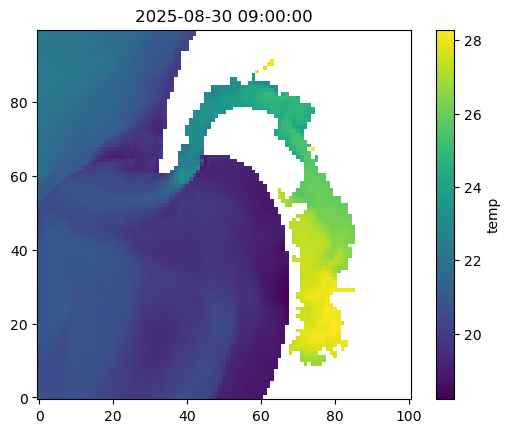

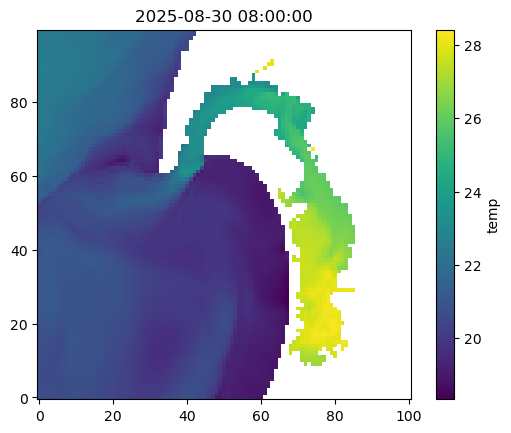

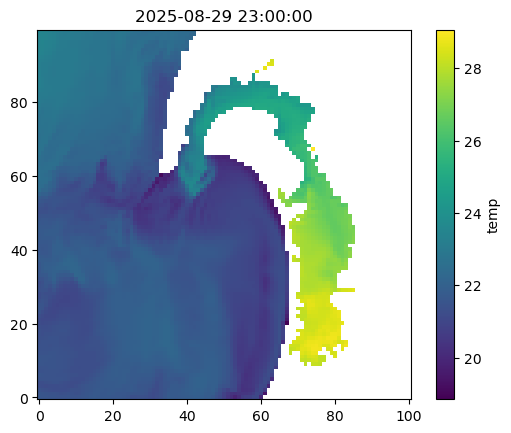

In [ ]:
iz=-1

fig, ax = plt.subplots()
itt = -1
temp = ds.variables['temp'][itt,iz,:,:]
im=ax.imshow(temp[150:250,150:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='temp')
ax.set_title(time_dt[itt])

fig, ax = plt.subplots()
itt = -2
temp = ds.variables['temp'][itt,iz,:,:]
im=ax.imshow(temp[150:250,150:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='temp')
ax.set_title(time_dt[itt])

fig, ax = plt.subplots()
itt = -11
temp = ds.variables['temp'][itt,iz,:,:]
im=ax.imshow(temp[150:250,150:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='temp')
ax.set_title(time_dt[itt])



In [5]:
fn_rst = '/scratch/PFM_Simulations/LV3_Forecast/His/some_files/LV3_ocean_rst_202508260000_202508310000.nc'
ds = nc.Dataset(fn_rst)
lat = ds.variables['lat_rho'][:]
lon = ds.variables['lon_rho'][:]
time0 = ds.variables['ocean_time']
time_dt = nc.num2date(time0[:], units=time0.units, calendar=time0.calendar)
#print(time_dt)
print(np.shape(ds.variables['temp'][:]))


(18, 2, 40, 413, 251)


Indices of overall maximum temp: (np.int64(3), np.int64(1), np.int64(0), np.int64(266), np.int64(203))
Indices of overall maximum salt: (np.int64(17), np.int64(1), np.int64(39), np.int64(266), np.int64(203))


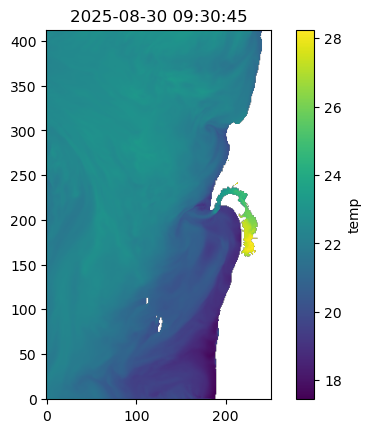

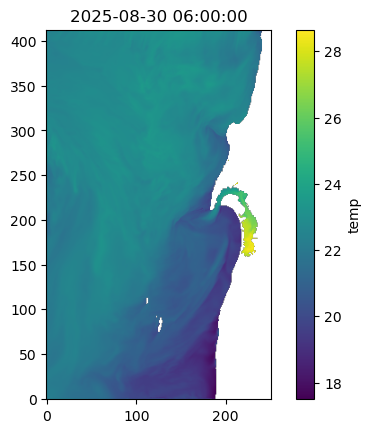

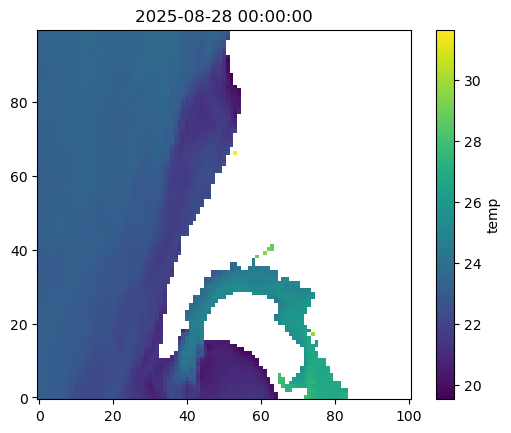

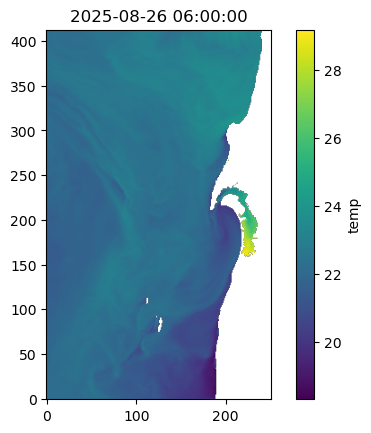

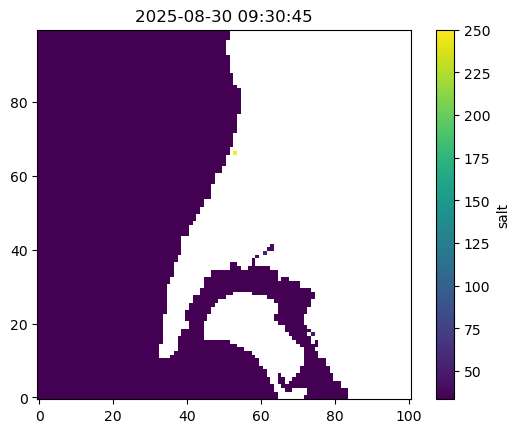

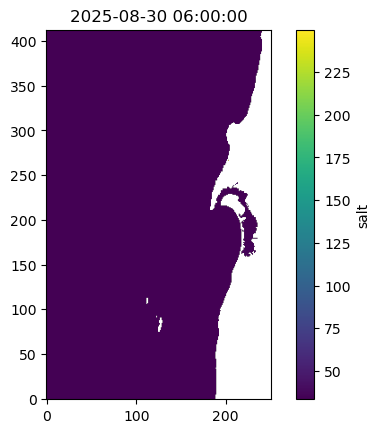

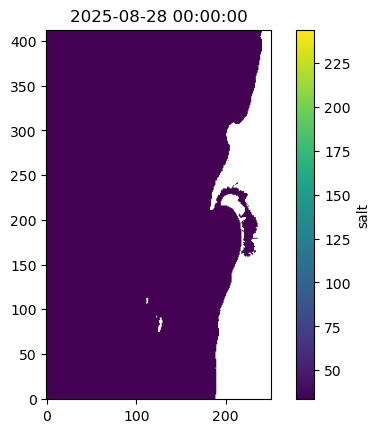

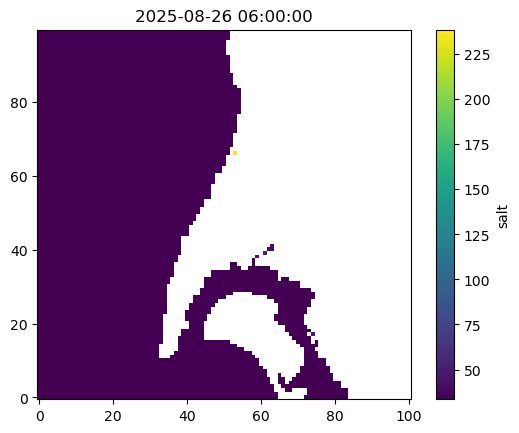

In [20]:
iz=-1
ibx = 203
iby = 266


fig, ax = plt.subplots()
itt = -1
temp = ds.variables['temp'][itt,1,iz,:,:]
im=ax.imshow(temp[:,:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='temp')
ax.set_title(time_dt[itt])

fig, ax = plt.subplots()
itt = -2
temp = ds.variables['temp'][itt,1,iz,:,:]
im=ax.imshow(temp[:,:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='temp')
ax.set_title(time_dt[itt])

fig, ax = plt.subplots()
itt = -11
temp = ds.variables['temp'][itt,1,iz,:,:]
im=ax.imshow(temp[200:300,150:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='temp')
ax.set_title(time_dt[itt])

fig, ax = plt.subplots()
itt = 0
temp = ds.variables['temp'][itt,1,iz,:,:]
im=ax.imshow(temp[:,:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='temp')
ax.set_title(time_dt[itt])

flat_max_index = np.argmax(ds.variables['temp'][:])
multi_dim_indices = np.unravel_index(flat_max_index, ds.variables['temp'][:].shape)
print(f"Indices of overall maximum temp: {multi_dim_indices}")

fig, ax = plt.subplots()
itt = -1
temp = ds.variables['salt'][itt,1,iz,:,:]
im=ax.imshow(temp[200:300,150:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='salt')
ax.set_title(time_dt[itt])

fig, ax = plt.subplots()
itt = -2
temp = ds.variables['salt'][itt,1,iz,:,:]
im=ax.imshow(temp[:,:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='salt')
ax.set_title(time_dt[itt])

fig, ax = plt.subplots()
itt = -11
temp = ds.variables['salt'][itt,1,iz,:,:]
im=ax.imshow(temp[:,:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='salt')
ax.set_title(time_dt[itt])

fig, ax = plt.subplots()
itt = 0
temp = ds.variables['salt'][itt,1,iz,:,:]
im=ax.imshow(temp[200:300,150:],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='salt')
ax.set_title(time_dt[itt])

flat_max_index = np.argmax(ds.variables['salt'][:])
multi_dim_indices = np.unravel_index(flat_max_index, ds.variables['salt'][:].shape)
print(f"Indices of overall maximum salt: {multi_dim_indices}")




In [28]:
fn_grd = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV3_rx020.nc'
ds_grd = nc.Dataset(fn_grd)
list_netcdf_contents(fn_grd)

msk_rho = ds_grd.variables['mask_rho'][:]
msk_u   = ds_grd.variables['mask_u'][:]
msk_v   = ds_grd.variables['mask_v'][:]
msk_psi = ds_grd.variables['mask_psi'][:]



--- Variables in /scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV3_rx020.nc ---
Variable: xl
  Dimensions: ('one',)
  Data Type: float64
  Attributes:
    long_name: domain length in the XI-direction
    units: meter
--------------------
Variable: el
  Dimensions: ('one',)
  Data Type: float64
  Attributes:
    long_name: domain length in the ETA-direction
    units: meter
--------------------
Variable: JPRJ
  Dimensions: ('two',)
  Data Type: |S1
  Attributes:
    long_name: Map projection type
    option_ME: Mercator
    option_ST: Stereographic
    option_LC: Lambert conformal conic
--------------------
Variable: spherical
  Dimensions: ('one',)
  Data Type: |S1
  Attributes:
    long_name: Grid type logical switch
    option_T: spherical
    option_F: Cartesian
--------------------
Variable: depthmin
  Dimensions: ('one',)
  Data Type: int16
  Attributes:
    long_name: domain length in the XI-direction
    units: meter
--------------------
Variable: depthmax
  Dimensions: ('one',)
  

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]]


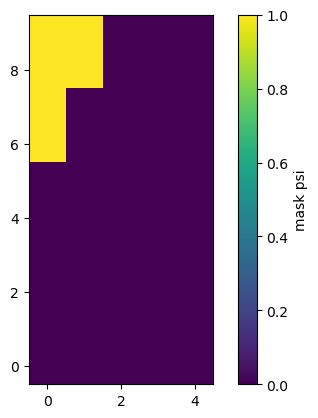

In [25]:
fig, ax = plt.subplots()
im=ax.imshow(msk_psi[260:270,200:205],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='mask psi')
print(msk_psi[260:270,200:205])


In [ ]:
fig, ax = plt.subplots()
im=ax.imshow(msk_rho[260:270,200:205],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='mask rho')
print(msk_rho[260:270,200:205])


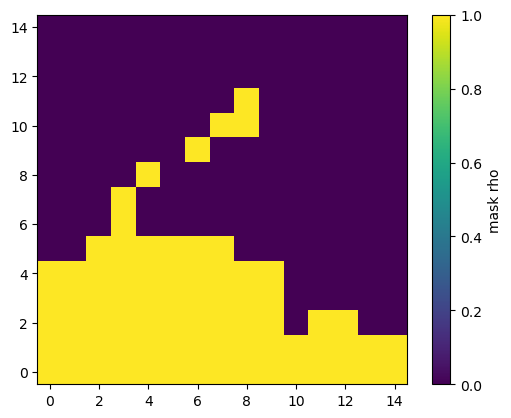

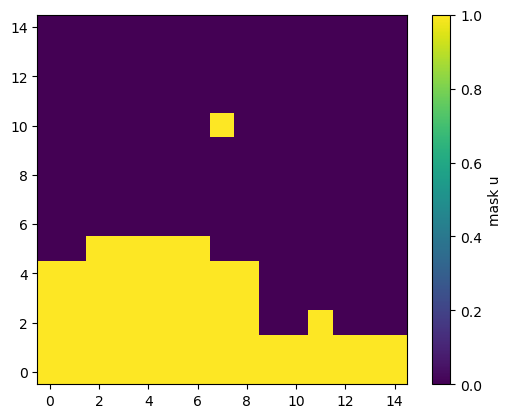

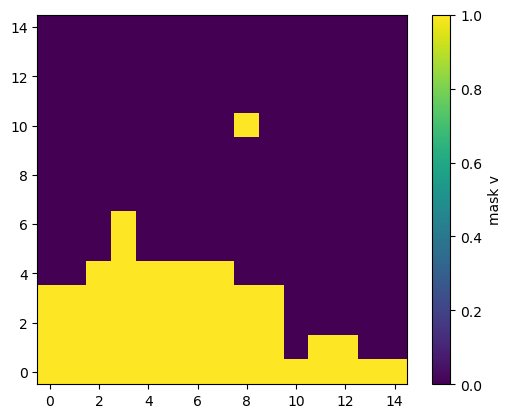

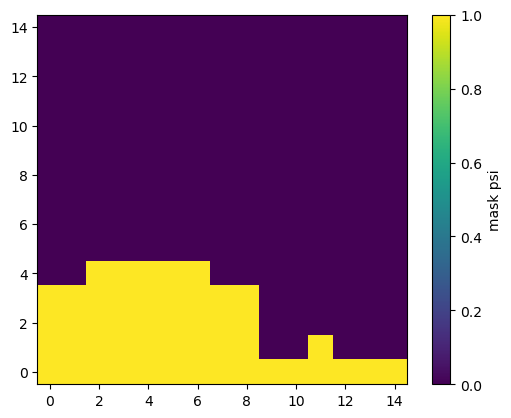

In [26]:
fig, ax = plt.subplots()
im=ax.imshow(msk_rho[230:245,205:220],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='mask rho')
fig, ax = plt.subplots()
im=ax.imshow(msk_u[230:245,205:220],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='mask u')
fig, ax = plt.subplots()
im=ax.imshow(msk_v[230:245,205:220],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='mask v')
fig, ax = plt.subplots()
im=ax.imshow(msk_psi[230:245,205:220],origin='lower') #, extent=[350, 450, 750, 850])
cbar = fig.colorbar(im, ax=ax, label='mask psi')

